# ALBATROS Tidal Elevation

- ALBATROS
    * Description: Decade-long most recently reprocessed CryoSat datasets, innovative information on bathymetry gradient location through the analysis of sea ice surface roughness characteristics, and the compilation of the best available datasets in ice-shelf regions.
    * Original Data Source: https://albatross.noveltis.fr/
    * Reference: https://albatross.noveltis.fr/publications/
    * OSC entry: 
        - https://opensciencedata.esa.int/products/tidal-elevation-amplitude-phase-tide-gauges/collection
        - https://opensciencedata.esa.int/products/tidal-elevation-cryosat2-2019/collection
        - https://opensciencedata.esa.int/products/tidal-elevation-GPS-FilchnerRonne-2009/collection 
        - https://opensciencedata.esa.int/products/tidal-elevation-tide-gauge-kerguelen/collection
    * License: CC-BY-NC-4.0
    * Repo Folder: ./datasets/albatross

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:

bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/albatross/elevation_prediction_cryosat2_SAR_A.parquet'

In [3]:
gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)
gdf['area'] = gdf.area

/tmp/ipykernel_18310/442944779.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area'] = gdf.area


In [4]:
time_col = "time"
value_col = "tidal_elevation_prediction_m"

source_crs = "EPSG:4326"
target_crs = "EPSG:3031"

grid_size_m = 25_000  # 25 km
target_date = "2019-04-03"

In [5]:
# subset daily data
start = pd.Timestamp(target_date)
end = start + pd.Timedelta(days=7)

gdf_day = gdf.loc[
    (gdf[time_col] >= start) &
    (gdf[time_col] < end)
].copy()

gdf_day = gdf_day.dropna(subset=[value_col])

In [6]:
# reproject and regrid
gdf_3031 = gdf_day.to_crs(target_crs)

from shapely.geometry import box

minx, miny, maxx, maxy = gdf_3031.total_bounds

# Snap grid bounds to the 25 km grid
minx = np.floor(minx / grid_size_m) * grid_size_m
miny = np.floor(miny / grid_size_m) * grid_size_m
maxx = np.ceil(maxx / grid_size_m) * grid_size_m
maxy = np.ceil(maxy / grid_size_m) * grid_size_m

x_edges = np.arange(minx, maxx + grid_size_m, grid_size_m)
y_edges = np.arange(miny, maxy + grid_size_m, grid_size_m)

grid_cells = []

for x0 in x_edges[:-1]:
    for y0 in y_edges[:-1]:
        x1 = x0 + grid_size_m
        y1 = y0 + grid_size_m

        grid_cells.append(
            {
                "geometry": box(x0, y0, x1, y1),
                "grid_x": x0,
                "grid_y": y0
            }
        )

grid = gpd.GeoDataFrame(grid_cells, crs=target_crs)

print(len(grid))
grid.head()

54516


,geometry,grid_x,grid_y
0,"POLYGON ((-2675000 -2825000, -2675000 -2800000...",-2700000.0,-2825000.0
1,"POLYGON ((-2675000 -2800000, -2675000 -2775000...",-2700000.0,-2800000.0
2,"POLYGON ((-2675000 -2775000, -2675000 -2750000...",-2700000.0,-2775000.0
3,"POLYGON ((-2675000 -2750000, -2675000 -2725000...",-2700000.0,-2750000.0
4,"POLYGON ((-2675000 -2725000, -2675000 -2700000...",-2700000.0,-2725000.0


In [7]:
# assign pints to grid cells
points_in_grid = gpd.sjoin(
    gdf_3031,
    grid[["grid_x", "grid_y", "geometry"]],
    how="inner",
    predicate="within"
)

points_in_grid.head()

,time,tidal_elevation_prediction_m,latitude,longitude,type,geometry,area,index_right,grid_x,grid_y
0,2019-04-03 00:42:11.249999872,-0.633424,-74.255775,-27.983294,cryosat2_SAR_A,POINT (-807545.282 1519840.711),0.0,17873,-825000.0,1500000.0
1,2019-04-03 00:42:11.249999872,-0.633644,-74.258522,-27.984816,cryosat2_SAR_A,POINT (-807443.055 1519550.893),0.0,17873,-825000.0,1500000.0
2,2019-04-03 00:42:11.249999872,-0.633204,-74.253021,-27.981771,cryosat2_SAR_A,POINT (-807647.89 1520131.283),0.0,17873,-825000.0,1500000.0
3,2019-04-03 00:42:11.249999872,-0.632985,-74.250275,-27.980249,cryosat2_SAR_A,POINT (-807750.089 1520421.117),0.0,17873,-825000.0,1500000.0
4,2019-04-03 00:42:11.249999872,-0.632766,-74.247520,-27.978729,cryosat2_SAR_A,POINT (-807852.721 1520711.678),0.0,17873,-825000.0,1500000.0


In [8]:
grid_avg = (
    points_in_grid
    .groupby(["grid_x", "grid_y"], as_index=False)
    .agg(
        avg_tidal_elevation_m=(value_col, "mean"),
        n_observations=(value_col, "count"),
        first_time=(time_col, "min"),
        last_time=(time_col, "max")
    )
)

grid_avg.head()

,grid_x,grid_y,avg_tidal_elevation_m,n_observations,first_time,last_time
0,-2700000.0,1950000.0,-0.073892,69,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
1,-2675000.0,1925000.0,-0.074791,81,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
2,-2675000.0,1950000.0,-0.074230,8,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
3,-2675000.0,1975000.0,-0.359437,30,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000
4,-2675000.0,2000000.0,-0.357388,21,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000


In [9]:
grid_result = grid.merge(
    grid_avg,
    on=["grid_x", "grid_y"],
    how="left"
)

grid_result_nonnull = grid_result.dropna(subset=["avg_tidal_elevation_m"]).copy()

grid_result_nonnull.head()

,geometry,grid_x,grid_y,avg_tidal_elevation_m,n_observations,first_time,last_time
191,"POLYGON ((-2675000 1950000, -2675000 1975000, ...",-2700000.0,1950000.0,-0.073892,69.0,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
426,"POLYGON ((-2650000 1925000, -2650000 1950000, ...",-2675000.0,1925000.0,-0.074791,81.0,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
427,"POLYGON ((-2650000 1950000, -2650000 1975000, ...",-2675000.0,1950000.0,-0.074230,8.0,2019-04-08 14:51:33.750000128,2019-04-08 14:51:33.750000128
428,"POLYGON ((-2650000 1975000, -2650000 2000000, ...",-2675000.0,1975000.0,-0.359437,30.0,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000
429,"POLYGON ((-2650000 2000000, -2650000 2025000, ...",-2675000.0,2000000.0,-0.357388,21.0,2019-04-06 14:54:22.500000000,2019-04-06 14:54:22.500000000


In [10]:
antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

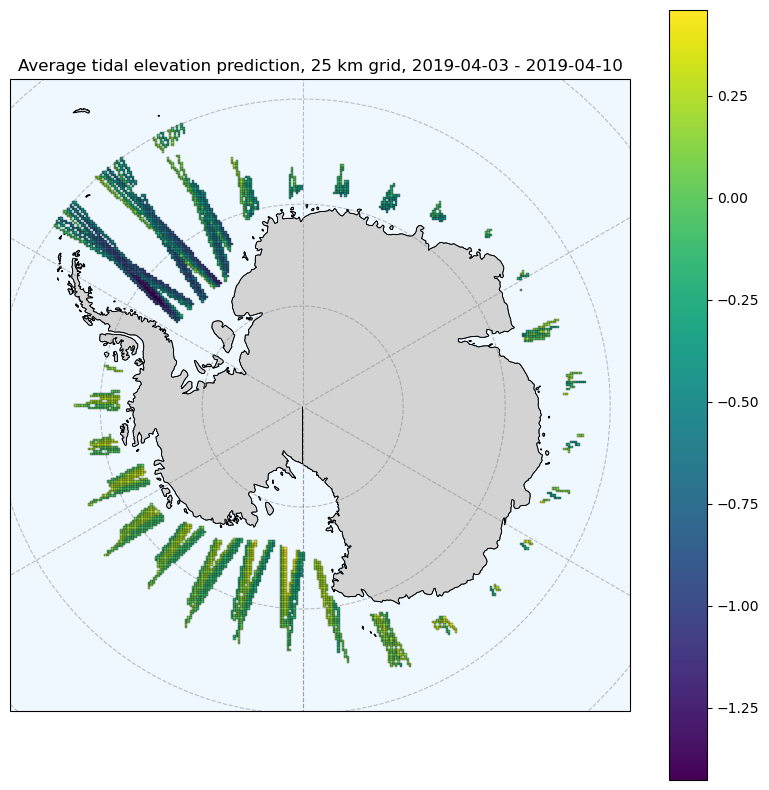

In [11]:
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": antarctic_crs},
)

ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", linewidth=0.4, zorder=1)
ax.coastlines(resolution="50m", color="black", linewidth=0.7, zorder=2)
ax.gridlines(draw_labels=False, color="gray", alpha=0.5, linestyle="--")


grid_result_nonnull.plot(
    column="avg_tidal_elevation_m",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    zorder=3,
)

minx, miny, maxx, maxy = grid_result_nonnull.total_bounds
pad = max(maxx - minx, maxy - miny) * 0.08
ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=antarctic_crs)

ax.set_title(f"Average tidal elevation prediction, 25 km grid, {start.date()} - {end.date()}")
ax.set_xlabel("EPSG:3031 x coordinate, metres")
ax.set_ylabel("EPSG:3031 y coordinate, metres")
ax.set_aspect("equal")

plt.show()